In [1]:
import pandas as pd

df = pd.read_csv("C:/projects/P1/sales_data.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,01-01-2022,S001,P0001,Electronics,North,195.0,102,252.0,72.72,5.0,Snowy,0.0,85.73,Winter,0,115
1,01-01-2022,S001,P0002,Clothing,North,117.0,117,249.0,80.16,15.0,Snowy,1.0,92.02,Winter,0,229
2,01-01-2022,S001,P0003,Clothing,North,247.0,114,612.0,62.94,10.0,Snowy,1.0,60.08,Winter,0,157
3,01-01-2022,S001,P0004,Electronics,North,139.0,45,102.0,87.63,10.0,Snowy,0.0,85.19,Winter,0,52
4,01-01-2022,S001,P0005,Groceries,North,152.0,65,271.0,54.41,1.0,Snowy,0.0,51.63,Winter,0,59


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146100 entries, 0 to 146099
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                146100 non-null  object 
 1   Store ID            146100 non-null  object 
 2   Product ID          146100 non-null  object 
 3   Category            146100 non-null  object 
 4   Region              146100 non-null  object 
 5   Inventory Level     143204 non-null  float64
 6   Units Sold          146100 non-null  int64  
 7   Units Ordered       143170 non-null  float64
 8   Price               143157 non-null  float64
 9   Discount            143230 non-null  float64
 10  Weather Condition   143155 non-null  object 
 11  Promotion           143158 non-null  float64
 12  Competitor Pricing  143176 non-null  float64
 13  Seasonality         146100 non-null  object 
 14  Epidemic            146100 non-null  int64  
 15  Demand              146100 non-nul

In [3]:
df.isnull().sum()

Date                     0
Store ID                 0
Product ID               0
Category                 0
Region                   0
Inventory Level       2896
Units Sold               0
Units Ordered         2930
Price                 2943
Discount              2870
Weather Condition     2945
Promotion             2942
Competitor Pricing    2924
Seasonality              0
Epidemic                 0
Demand                   0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [6]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [7]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level       float64
Units Sold              int64
Units Ordered         float64
Price                 float64
Discount              float64
Weather Condition      object
Promotion             float64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [8]:
# Convert numeric columns
df['Inventory Level'] = df['Inventory Level'].astype(int)
df['Units Ordered'] = df['Units Ordered'].astype(int)
df['Units Sold'] = df['Units Sold'].astype(int)
df['Promotion'] = df['Promotion'].astype(int)

# Convert categorical columns
df['Category'] = df['Category'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Weather Condition'] = df['Weather Condition'].astype('category')
df['Seasonality'] = df['Seasonality'].astype('category')

In [9]:
df.dtypes

Date                    object
Store ID                object
Product ID              object
Category              category
Region                category
Inventory Level          int64
Units Sold               int64
Units Ordered            int64
Price                  float64
Discount               float64
Weather Condition     category
Promotion                int64
Competitor Pricing     float64
Seasonality           category
Epidemic                 int64
Demand                   int64
dtype: object

In [10]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.strip().str.replace(" ", "_")

df['Category'] = df['Category'].str.strip()
df['Region'] = df['Region'].str.strip()
df['Weather_Condition'] = df['Weather_Condition'].str.strip()
df['Seasonality'] = df['Seasonality'].str.strip()

In [11]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [12]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

In [13]:
df["Revenue"] = df["Units_Sold"] * df["Price"]

df["Discount_Amount"] = df["Price"] * (0.01*df["Discount"])

df["Final_Price"] = df["Price"] - df["Discount_Amount"]

cols = list(df.columns)

# remove newly added columns
cols.remove("Revenue")
cols.remove("Discount_Amount")
cols.remove("Final_Price")

# find weather position
pos = cols.index("Weather_Condition")

# insert at correct position
cols.insert(pos, "Revenue")
cols.insert(pos + 1, "Discount_Amount")
cols.insert(pos + 2, "Final_Price")

# apply order
df = df[cols]

In [14]:
df['Units_Sold'].sum()

np.int64(10990157)

In [15]:
df.groupby('Category')['Units_Sold'].sum().sort_values(ascending=False)

Category
Groceries      4868149
Clothing       1827362
Toys           1505494
Furniture      1410979
Electronics    1378173
Name: Units_Sold, dtype: int64

In [16]:
df.groupby('Region')['Units_Sold'].sum().sort_values(ascending=False)

Region
North    4201313
East     2474004
South    2243726
West     2071114
Name: Units_Sold, dtype: int64

In [17]:
df.columns

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Region',
       'Inventory_Level', 'Units_Sold', 'Units_Ordered', 'Price', 'Discount',
       'Revenue', 'Discount_Amount', 'Final_Price', 'Weather_Condition',
       'Promotion', 'Competitor_Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Year', 'Month', 'Day', 'Weekday'],
      dtype='object')

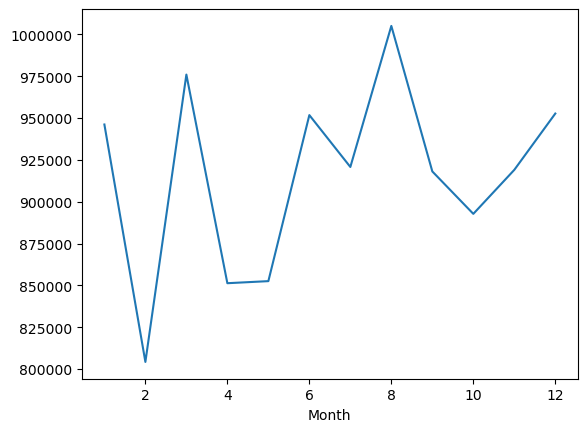

In [18]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Units_Sold'].sum()

plt.ticklabel_format(style='plain', axis='y')
monthly_sales.plot()

plt.show()

In [19]:
df.to_csv("C:/projects/P1/clean_retail_data.csv", index=False)